<a href="https://colab.research.google.com/github/roxaaaaa/Predictive-Analytics/blob/main/ca1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CA1: Predictive Regression Modelling Assignment

Student Name : Roksolana Kryvulia

Student L Number : L00188404

Tasks for Regressio (copied from assignement overview):
1. Download or use the assigned unique dataset to will allow you to perform predictive analysis.
2. Exploratory Data Analysis: Explore the data and its features and any other statistical measure to
assist in the prediction analysis. Discuss any data observations that may impact the models.
3. Perform any cleaning and data preparation if required. Discuss and explain why the particular
cleaning and data preparation was used.
4. Identify the prediction that may be made after the data analysis
5. Perform:
*   Linear Regression
*   Multiple Linear Regression
*   Polynomial Regression Model
*   Logistic Regression
6. The student should have more than one model for each regression type.
a. E.g. for Linear Regression perform the regression, review and explain the metrics.
Why does the metrics give the value it has and was this expected after performing
the exploratory data analysis.
b. Identify another independent variable to use and perform at least 1 other regression
analysis, explain why this variable was chosen, review and explain the metrics and
compare to the first model.

7. Discuss and explain what the metric results indicate. A student must use a combination of metrics
will indicate whether a model is a good fit or not. Knowing why a model is/is not a good fit is
required.
8. Provide explanation as to why the particular library was chosen. The student must take into
consideration that multiple python libraries can be used. Using more than one library and
providing comparison of the models is recommended.


In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

The UCI fetcher automatically splits features and targets into two separate dataframes (X and y).

After some time trying to figure it out(align X and Y indexed, add columns to X then drop them later, keep track of which target to use for which model),I decided to merge it in one dataframe.

In [24]:
df = wine_quality.data.features.copy()
df['quality'] = wine_quality.data.targets['quality'].values

In [25]:
display(df.describe())

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


residual_sugar usually stays below about 8.1 (75%).
But the maximum is 65.8, which is extremely high. That means there are some unusual wines with very high sugar that could skew the model.

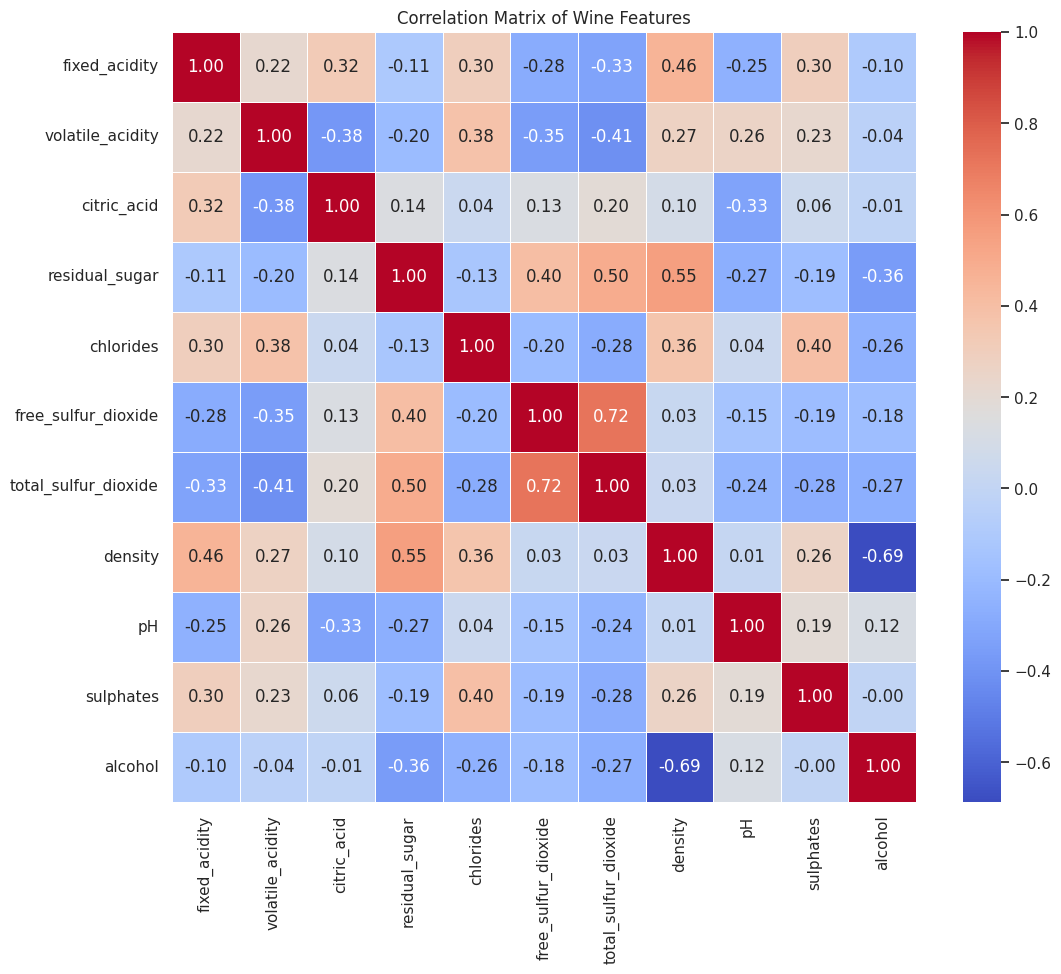

In [26]:
# Calculate the correlation matrix (exclude quality)
corr_matrix = df.drop(columns=['quality']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Wine Features')
plt.show()

**Density and Residual Sugar → strong positive correlation** *0.55*
 When sugar goes up, density tends to go up too.
(More sugar makes the liquid heavier.)

**Alcohol and Density → negative correlation** *-0.69*
When alcohol increases, density tends to decrease.

**Free vs Total Sulfur Dioxide → highly correlated** *0.72*
These two measurements move very closely together.

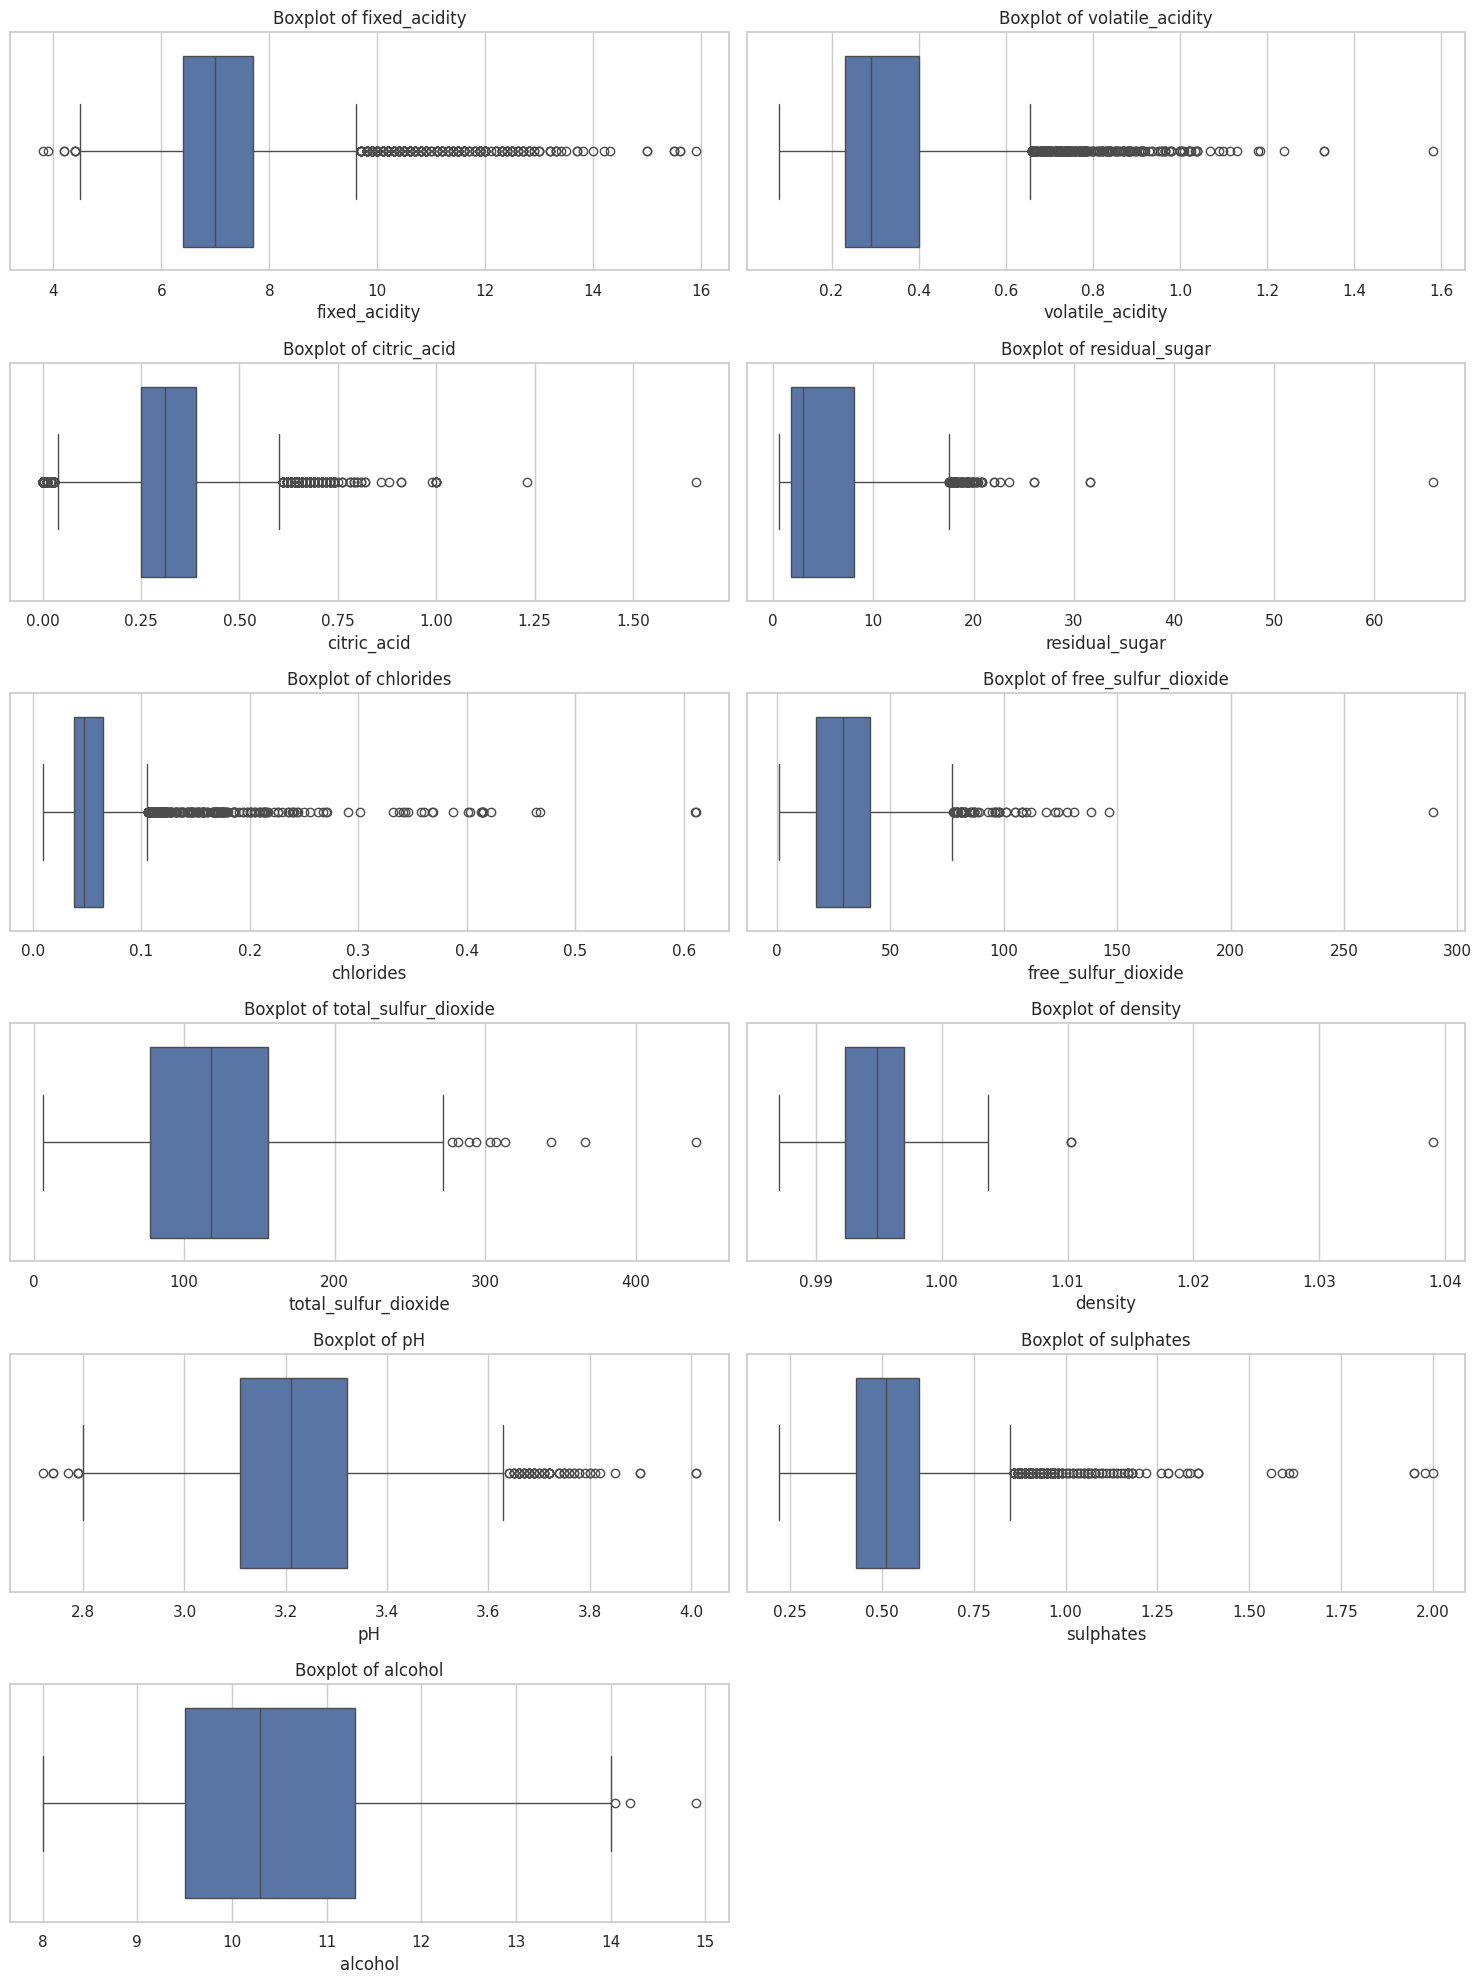

In [27]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(15, 20))
features = df.drop(columns=['quality']).columns

for i, col in enumerate(features):
    plt.subplot(6, 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Strongly right skewed outliners:

*   Residual sugar

*   Chlorides

*   Volatile acidity

I only cleaned residual_sugar, chlorides, and volatile_acidity because these were the columns selected for analysis. Cleaning columns not used in modeling is unnecessary.

In [28]:
for i in ["residual_sugar", "chlorides", "volatile_acidity"]:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    print(f"{i} upper bound: {upper}")
    df = df[df[i] <= upper]

residual_sugar upper bound: 17.549999999999997
chlorides upper bound: 0.10550000000000001
volatile_acidity upper bound: 0.67


if value in *residual_sugar* is over **17.5497**, it means it is outlier

if value in *chlorides* is over **0.1055**, it means it is outlier

if value in *volatile acidity* is over **0.655**, it means it is outlier



By applying this transformation, I compress the range of the outliers and make the distribution of these features more normal.

This helps linear regression models perform better because it prevents extreme values from having a negativew and too much impact on the model's coefficients.

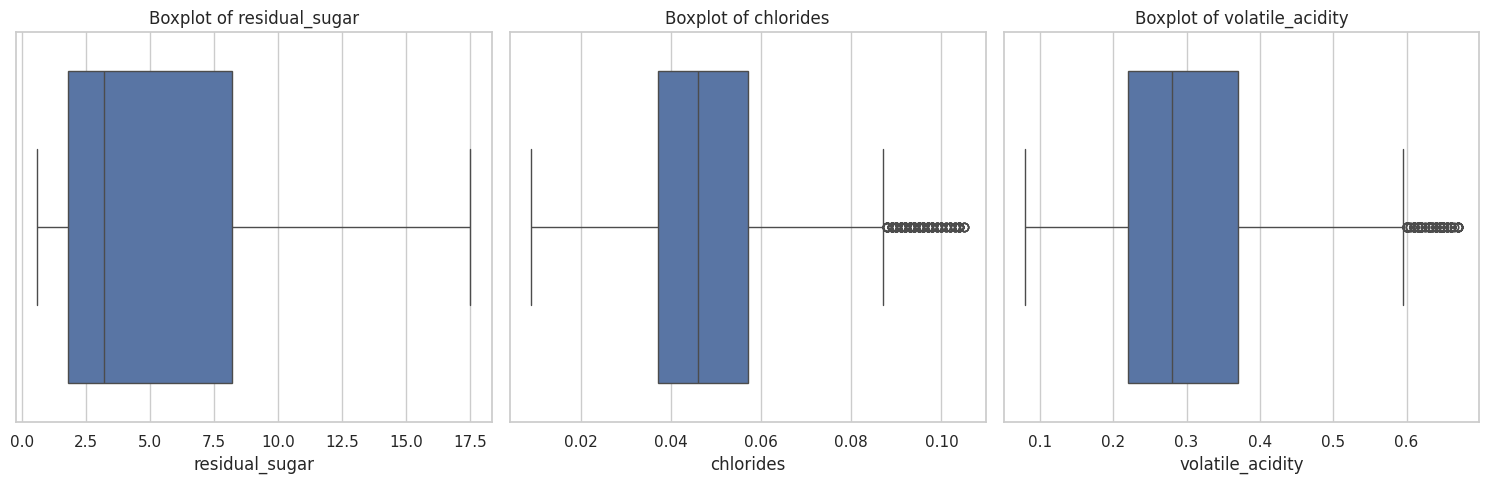

In [33]:
plt.figure(figsize=(15, 5))
features = ["residual_sugar", "chlorides", "volatile_acidity"]

for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [34]:
df['high_quality'] = [1 if x >= 7 else 0 for x in df['quality']]

print(df['high_quality'].value_counts())
print(df['high_quality'].value_counts(normalize=True) * 100)

high_quality
0    4579
1    1244
Name: count, dtype: int64
high_quality
0    78.636442
1    21.363558
Name: proportion, dtype: float64


distribution is 78.6% / 21.4%.

78.6% of low quality wine (0) and 21.4% of high quality wine (1) in dataset. Imbalanced but acceptable disctribution.

In [35]:
# Define features and targets
X = df.drop(columns=['quality', 'high_quality'])
y_regression = df['quality']
y_classification = df['high_quality']

In [36]:
from sklearn.model_selection import train_test_split

# For Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y_regression, test_size=0.2, random_state=42)

# For Logistic Regression
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_classification, test_size=0.2, random_state=42)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Regression
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
X_train_cls_scaled = scaler.fit_transform(X_train_cls)
X_test_cls_scaled = scaler.transform(X_test_cls)

In [38]:
print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (4658, 11)
Test set: (1165, 11)


11 columns = 11 wine features (after dropping quality and high_quality)

80/20 split = 4658 + 1165 = 5823 total rows (original 6497 minus outliers removed)

# Model 1: Linear Regression Alcohol vs Quality

I chosed Alcohol as the independent variable for the first linear regression model because it has the strongest and most direct relationship with wine quality. Wines with higher alcohol content tend to receive better quality ratings.

Linear Regression Model 1 - Alcohol
R² Score:  0.1931
MSE:       0.5927
RMSE:      0.7698


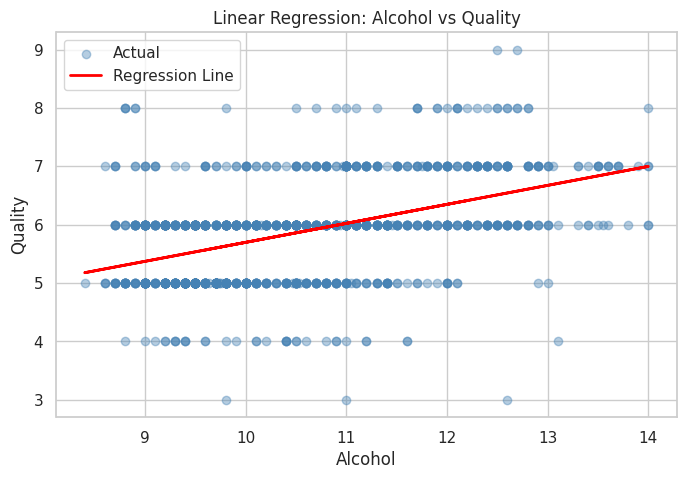

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Select single feature
X_train_lr = X_train[['alcohol']]
X_test_lr = X_test[['alcohol']]

# Train model
lr_model1 = LinearRegression()
lr_model1.fit(X_train_lr, y_train)

# Predict
y_pred_lr1 = lr_model1.predict(X_test_lr)

# Metrics
r2 = r2_score(y_test, y_pred_lr1)
mse = mean_squared_error(y_test, y_pred_lr1)
rmse = np.sqrt(mse)

print("Linear Regression Model 1 - Alcohol")
print(f"R² Score:  {r2:.4f}")
print(f"MSE:       {mse:.4f}")
print(f"RMSE:      {rmse:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_test_lr, y_test, color='steelblue', alpha=0.4, label='Actual')
plt.plot(X_test_lr, y_pred_lr1, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.title('Linear Regression: Alcohol vs Quality')
plt.legend()
plt.show()

Model explains only 19% of variance in quality. This weak fit is explanable, beavuse the wine queality is complex outocme influenced by myne chemicals not just alcohol alone

# Model 2: residual_sugar vs Quality

I selected residual sugar for the second model because sweetness is an important feature in judging wine quality. Sweet wines are often rated highly, so I think there may be a positive relationship between residual sugar and quality scores.

Linear Regression Model 2 Sugar
R² Score:  -0.0022
MSE:       0.7361
RMSE:      0.8580


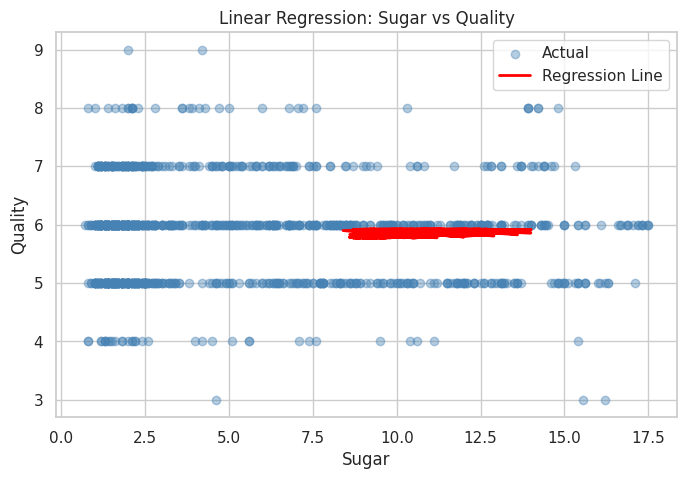

In [45]:
# Select single feature
X_train_lr2 = X_train[['residual_sugar']]
X_test_lr2 = X_test[['residual_sugar']]

# Train model
lr_model2 = LinearRegression()
lr_model2.fit(X_train_lr2, y_train)

# Predict
y_pred_lr2 = lr_model2.predict(X_test_lr2)

# Metrics
r2_2 = r2_score(y_test, y_pred_lr2)
mse_2 = mean_squared_error(y_test, y_pred_lr2)
rmse_2 = np.sqrt(mse_2)

print("Linear Regression Model 2 Sugar")
print(f"R² Score:  {r2_2:.4f}")
print(f"MSE:       {mse_2:.4f}")
print(f"RMSE:      {rmse_2:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_test_lr2, y_test, color='steelblue', alpha=0.4, label='Actual')
plt.plot(X_test_lr, y_pred_lr2, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Sugar')
plt.ylabel('Quality')
plt.title('Linear Regression: Sugar vs Quality')
plt.legend()
plt.show()

A negative R square means the model is performing worse than just predicting the mean value every time. Residual sugar has no linear relationship with quality at all.

In [47]:

# Multiple Regression
# Model 1 All features

lr_multi1 = LinearRegression()
lr_multi1.fit(X_train_scaled, y_train)

y_pred_multi1 = lr_multi1.predict(X_test_scaled)

r2_m1 = r2_score(y_test, y_pred_multi1)
mse_m1 = mean_squared_error(y_test, y_pred_multi1)
rmse_m1 = np.sqrt(mse_m1)

print("Multiple Regression Model 1 All Features")
print(f"R² Score:  {r2_m1:.4f}")
print(f"MSE:       {mse_m1:.4f}")
print(f"RMSE:      {rmse_m1:.4f}")

Multiple Regression Model 1 All Features
R² Score:  0.2809
MSE:       0.5281
RMSE:      0.7267


In [49]:
# Multiple Regression Model 2
# Alcohol, Volatile Acidity, Sulphates, Citric Acid Features
# Those features most likely to impact quality

selected_features = ['alcohol', 'volatile_acidity', 'sulphates', 'citric_acid']

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

scaler2 = StandardScaler()
X_train_sel_scaled = scaler2.fit_transform(X_train_sel)
X_test_sel_scaled = scaler2.transform(X_test_sel)

lr_multi2 = LinearRegression()
lr_multi2.fit(X_train_sel_scaled, y_train)

y_pred_multi2 = lr_multi2.predict(X_test_sel_scaled)

r2_m2 = r2_score(y_test, y_pred_multi2)
mse_m2 = mean_squared_error(y_test, y_pred_multi2)
rmse_m2 = np.sqrt(mse_m2)

print("Multiple Regression Model 2")
print(f"R² Score:  {r2_m2:.4f}")
print(f"MSE:       {mse_m2:.4f}")
print(f"RMSE:      {rmse_m2:.4f}")

Multiple Regression Model 2
R² Score:  0.2576
MSE:       0.5453
RMSE:      0.7384


Multiple Regression Model 1, which used all 11 features, achieved an R square of 0.28. This is better than the single-feature linear regression, which had an R square of 0.19.

I think this shows that wine quality depends on a mix of chemical properties rather than just one variable. However, the R square is still quite low, so linear relationships alone cannot fully explain wine quality. Because of this, I decided to try polynomial regression.

In [50]:
from sklearn.preprocessing import PolynomialFeatures

from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

# Polynomial Regression Model 1: Alcohol degree 2

X_train_poly1 = X_train[['alcohol']]
X_test_poly1 = X_test[['alcohol']]

pr = PolynomialFeatures(degree=2)
X_train_poly1_transformed = pr.fit_transform(X_train_poly1)
X_test_poly1_transformed = pr.transform(X_test_poly1)

poly_model1 = linear_model.LinearRegression()
poly_model1.fit(X_train_poly1_transformed, y_train)

y_pred_poly1 = poly_model1.predict(X_test_poly1_transformed)

r2_p1 = r2_score(y_test, y_pred_poly1)
mse_p1 = mean_squared_error(y_test, y_pred_poly1)
rmse_p1 = np.sqrt(mse_p1)

print("Polynomial Regression Model 1: Alcohol (degree 2)")
print(f"R² Score:  {r2_p1:.4f}")
print(f"MSE:       {mse_p1:.4f}")
print(f"RMSE:      {rmse_p1:.4f}")

Polynomial Regression Model 1: Alcohol (degree 2)
R² Score:  0.1954
MSE:       0.5910
RMSE:      0.7688


In [51]:
#Polynomial Regression Model 2: Alcohol & Volatile acidity degree 2

X_train_poly2 = X_train[['alcohol', 'volatile_acidity']]
X_test_poly2 = X_test[['alcohol', 'volatile_acidity']]

pr2 = PolynomialFeatures(degree=2)
X_train_poly2_transformed = pr2.fit_transform(X_train_poly2)
X_test_poly2_transformed = pr2.transform(X_test_poly2)

poly_model2 = linear_model.LinearRegression()
poly_model2.fit(X_train_poly2_transformed, y_train)

y_pred_poly2 = poly_model2.predict(X_test_poly2_transformed)

r2_p2 = r2_score(y_test, y_pred_poly2)
mse_p2 = mean_squared_error(y_test, y_pred_poly2)
rmse_p2 = np.sqrt(mse_p2)

print("Polynomial Regression Model 2: Alcohol + Volatile Acidity (degree 2)")
print(f"R² Score:  {r2_p2:.4f}")
print(f"MSE:       {mse_p2:.4f}")
print(f"RMSE:      {rmse_p2:.4f}")

Polynomial Regression Model 2: Alcohol + Volatile Acidity (degree 2)
R² Score:  0.2535
MSE:       0.5483
RMSE:      0.7404


Polynomial Regression Model 1, using alcohol with degree 2, achieved an R² of 0.1954. This only slightly improved on the linear regression model, which had an R² of 0.1931. I think this means the relationship between alcohol and quality is mostly linear, with no strong curved pattern.

Model 2, which combined alcohol and volatile acidity, improved the R² to 0.2535. However, neither polynomial model performed better than the Multiple Regression model that used all features (R² = 0.2809). I think this shows that using more relevant features improves prediction more than simply increasing polynomial complexity for this dataset.

Multiple Regression Model 1 remains the best model so far.

=== Logistic Regression Model 1 - All Features ===
Accuracy: 0.8094

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       935
           1       0.53      0.29      0.37       230

    accuracy                           0.81      1165
   macro avg       0.69      0.61      0.63      1165
weighted avg       0.78      0.81      0.79      1165



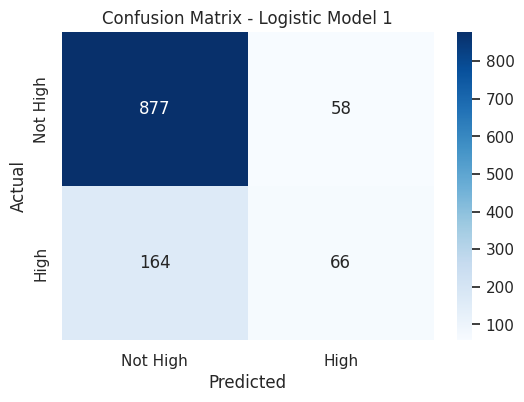

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#Logistic Regression Model 1: all features

log_model1 = LogisticRegression(max_iter=1000)
log_model1.fit(X_train_cls_scaled, y_train_cls)

y_pred_log1 = log_model1.predict(X_test_cls_scaled)

print("=== Logistic Regression Model 1 - All Features ===")
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_log1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_log1))

# Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_log1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High', 'High'],
            yticklabels=['Not High', 'High'])
plt.title('Confusion Matrix - Logistic Model 1')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Logistic Regression Model 2
Accuracy: 0.8112

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       935
           1       0.55      0.25      0.35       230

    accuracy                           0.81      1165
   macro avg       0.69      0.60      0.62      1165
weighted avg       0.78      0.81      0.78      1165



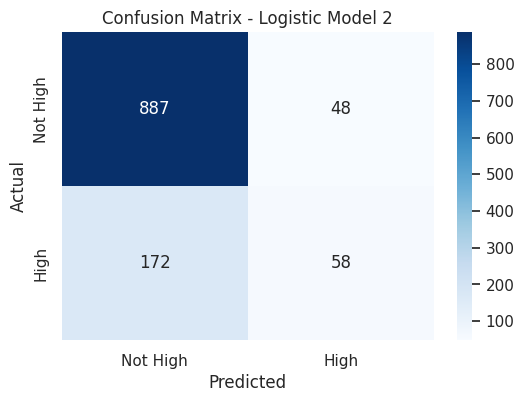

In [55]:
# Logistic Regression Model 2: selected features

selected_cls = ['alcohol', 'volatile_acidity', 'sulphates', 'citric_acid']

X_train_cls2 = X_train[selected_cls]
X_test_cls2 = X_test[selected_cls]

scaler_cls2 = StandardScaler()
X_train_cls2_scaled = scaler_cls2.fit_transform(X_train_cls2)
X_test_cls2_scaled = scaler_cls2.transform(X_test_cls2)

log_model2 = LogisticRegression(max_iter=1000)
log_model2.fit(X_train_cls2_scaled, y_train_cls)

y_pred_log2 = log_model2.predict(X_test_cls2_scaled)

print("Logistic Regression Model 2")
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_log2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_log2))

# Confusion Matrix
cm2 = confusion_matrix(y_test_cls, y_pred_log2)
plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High', 'High'],
            yticklabels=['Not High', 'High'])
plt.title('Confusion Matrix - Logistic Model 2')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Both logistic regression models achieved about 81% accuracy. However, I think this result is misleading because of class imbalance. The model performs well on class 0 (F1 = 0.89) but performs poorly on class 1 (high-quality wines), with an F1 score of only 0.37.

The low recall of 0.29 for class 1 means the model fails to identify 71% of truly high-quality wines. I think this happens because of the 78/22 class imbalance found during EDA, where the majority class has too much influence during training.

Model 2, which used selected features, performed similarly to Model 1. I think this suggests that the extra features add very little value for this classification task.